In [1]:
# In this step, we are importing all the requred dependencies.

import pandas as pd # for data processing
import numpy as np # for working with arrays
import matplotlib.pyplot as plt # for visualization
from termcolor import colored as cl # for text customization

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # for using determine the performance of the model

We are using the publicly available Credit Card Fraud Detection dataset downloaded from Kaggle. (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

In [2]:
# Loading the dataset in a Pandas dataframe. 
dataset = pd.read_csv('creditcard.csv')

In [3]:
# We just verify that the loading of the dataset is successful, and we also see the first 5 records of our dataset. 
dataset.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# We now append the beginning of the dataset to the end of the dataset to find out how many rows we have in our dataset.
pd.concat([dataset.head(), dataset.tail()])

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
# We drop our the 'Time' columnn since it will never be needed for training our model and then again have a look at dataset, this time without the 'Time' column.
dataset.drop('Time', axis = 1, inplace = True)

In [6]:
# Now we have a look at our dataset without the 'Time' axis, using the same command performed earlier. 
pd.concat([dataset.head(), dataset.tail()])

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


Now our dataset is ready for pre-processing. We have a dataset with a total of 284806 records and without the 'Time' column. The 'V1 - V28' columns have the customer's data and credit card data which are very sensitive and cannot be exposed to public view. It has been interestingly converted into their numerical form through a process called "Principal Component Analysis" which masks the details and instead displays numbers. It also has the 'Amount' column representing the amount the transaction, and the 'Class' column which is the most important part of the dataset. The value "0" in the class column represents a Legit transaction, while a 1 in the class column represents a fraudulent transaction.

# Data Preprocessing

Now we start preparing our dataset for training our model.

In [7]:
# We first check for the number of rows that has the value "0" in their 'Class' column, and the number of rows that has the value "1".
# And then we print the number of Fraudulent Cases and the number of Legit Transactions, and then have a percentage of the transactions that are fraudulent.

cases = len(dataset)
legit_count = len(dataset[dataset.Class == 0])
fraud_count = len(dataset[dataset.Class == 1])
fraud_percentage = round(fraud_count/legit_count*100, 2)

# We will be making use of the termcolour library that we imported at the beginning of this project for making the headers and information bold.
print(cl('Data Count', attrs = ['bold']))
print(cl('--------------------------------------------', attrs = ['bold']))
print(cl('Total number of transactions in the dataset: {}'.format(cases), attrs = ['bold']))
print(cl('Number Legit transactions: {}'.format(legit_count), attrs = ['bold']))
print(cl('Number of Fraudulent transactions: {}'.format(fraud_count), attrs = ['bold']))
print(cl('Percentage of transactions that are Fraudulent: {}'.format(fraud_percentage), attrs = ['bold']))
print(cl('--------------------------------------------', attrs = ['bold']))

Data Count
--------------------------------------------
Total number of transactions in the dataset: 284807
Number Legit transactions: 284315
Number of Fraudulent transactions: 492
Percentage of transactions that are Fraudulent: 0.17
--------------------------------------------


<Axes: ylabel=' '>

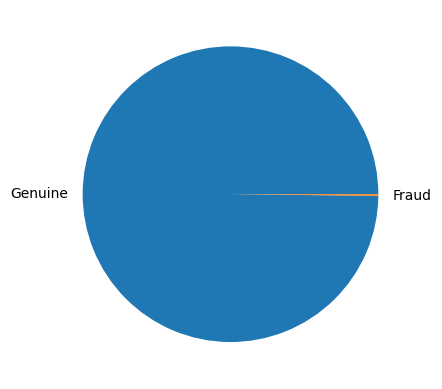

In [8]:
# We now plot a pie-chart to depict only a very small part of our dataset has fradulent transactions. 
data_piechart = dataset.copy()
data_piechart[" "] = np.where(data_piechart["Class"] == 1 ,  "Fraud", "Genuine")
data_piechart[" "].value_counts().plot(kind="pie")

In [9]:
# Now we move forward towards getting more data about our transaction cases from the dataset. 
legit_trans = dataset[dataset.Class == 0]
fraud_trans = dataset[dataset.Class == 1]

# In both these lines, we declare variables for the legit and fraud cases and separate out the rows that have the "0" in the 'Class' column and "1" in the 'Class' column
# This step is also going to help us for separating the data for analysis.

In [10]:
# Now we go for checking if things went right, and we see that our legit_trans variable has got 284315 items, while our fraud_trans variable has got 492 variables just as it should have been. And we have 30 columns, and not 31 (like the dataset), as we had dropped out the 'Time' column at the very beginning.
print(legit_trans.shape)
print(fraud_trans.shape)

(284315, 30)
(492, 30)


In [11]:
# No we will go forward and see some statistical view of the 'Amonunt' column of the Fraudulent and Legit transactions. 
print(cl('CASE STATISTICS', attrs = ['bold']))
print(cl('--------------------------------------------', attrs = ['bold']))
print(cl('Amount details of the Legit Transaction', attrs = ['bold']))
print(legit_trans.Amount.describe())
print(cl('--------------------------------------------', attrs = ['bold']))
print(cl('Amount details of the Fraudulent Transaction', attrs = ['bold']))
print(fraud_trans.Amount.describe())
print(cl('--------------------------------------------', attrs = ['bold']))

CASE STATISTICS
--------------------------------------------
Amount details of the Legit Transaction
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64
--------------------------------------------
Amount details of the Fraudulent Transaction
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64
--------------------------------------------


Representations
count - Number of cases
mean - Average
std - Standard Deviation(Standard deviation is a measure of how much the data deviates from the mean. In the case of Amount, a high standard deviation indicates that the amount values are spread out over a wide range of values.)
min - Minimum value
25% - 25 percentile of the transactions are below 5.65 in the 'Amount' column.
50% - 50 percentile of the transactions are below 22.00 in the 'Amount' column.
75% - 75 percentile of the transactions are below 77.05 in the 'Amount' column.
max - Maximum value

In [12]:
# Our final step before we move onto Processing our data for training our model is to check for missing (null) values in the dataset. 

dataset.isnull().values.any()

False

We this see that there are no missing values in the dataset, which makes us lucky because we don't have to go through the inputation process to handle the missing values. We can now start preparing our dataset for processing.

So, now Preprocessing is more of less complete, we are now going to move forward to processsing our data for training our model. 

# Processing our data

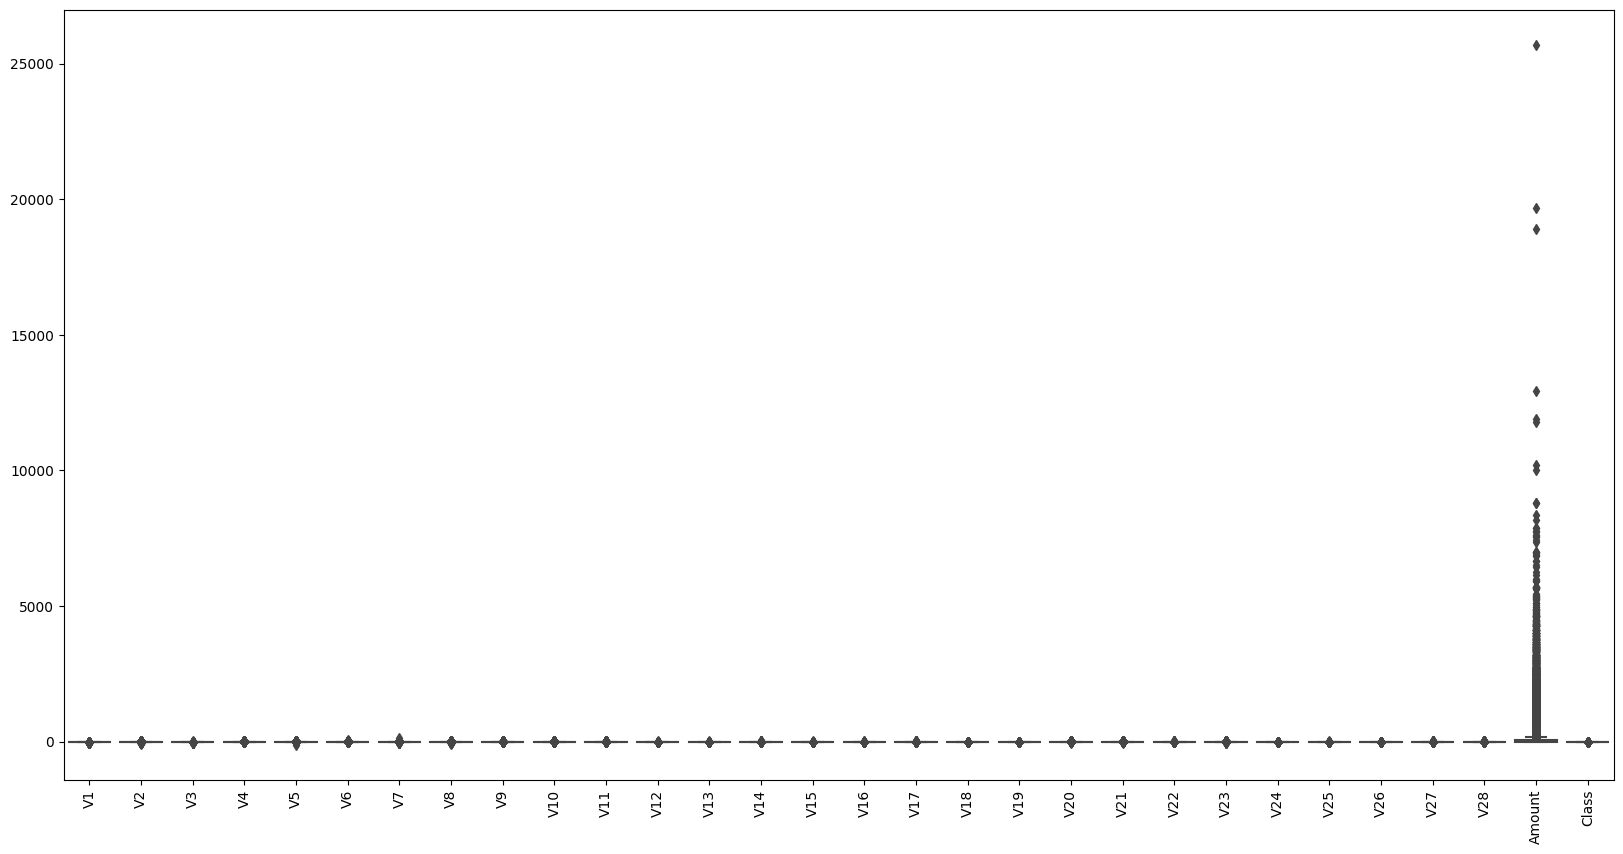

In [13]:
# The first step in processing our data is to find for outliers if any are present and then we can move forward to scaling our data before we start training our model. 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
sns.boxplot(data=dataset)
plt.xticks(rotation=90)
plt.show()


We thus see that the 'Amount' column has the greatest number of outliers and therefore we need to scale the column before we go any further.

In [14]:
# For scaling the 'Amount' column, we use the RobustScaler. It is preferred over Standard Scaler in the Amount column because the amount column has outliers that can affect the mean and standard deviation used by the Standard Scaler. 
# Robust Scaler uses the median and interquartile range to scale the data, making it more resistant to the effect of outliers. 
# On the other hand, Standard Scaler scales the data based on the mean and standard deviation, making it sensitive to the outliers. Therefore, in the presence of outliers, Robust Scaler is a better choice to ensure the data is scaled properly.

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler().fit(dataset[["Amount"]])
dataset[["Amount"]] = scaler.transform(dataset[["Amount"]])

pd.concat([dataset.head(), dataset.tail()])

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,0
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,-0.296653,0
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0.038986,0
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0.641096,0
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,-0.167680,0
284806,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,2.724796,0


When we see the 'Amount' column we see that it has got a new set of values that was not present before we scaled our dataset.
We are going to redo the plotting to see if the RobustScaler has trully worked or not, and so we run the same code again.

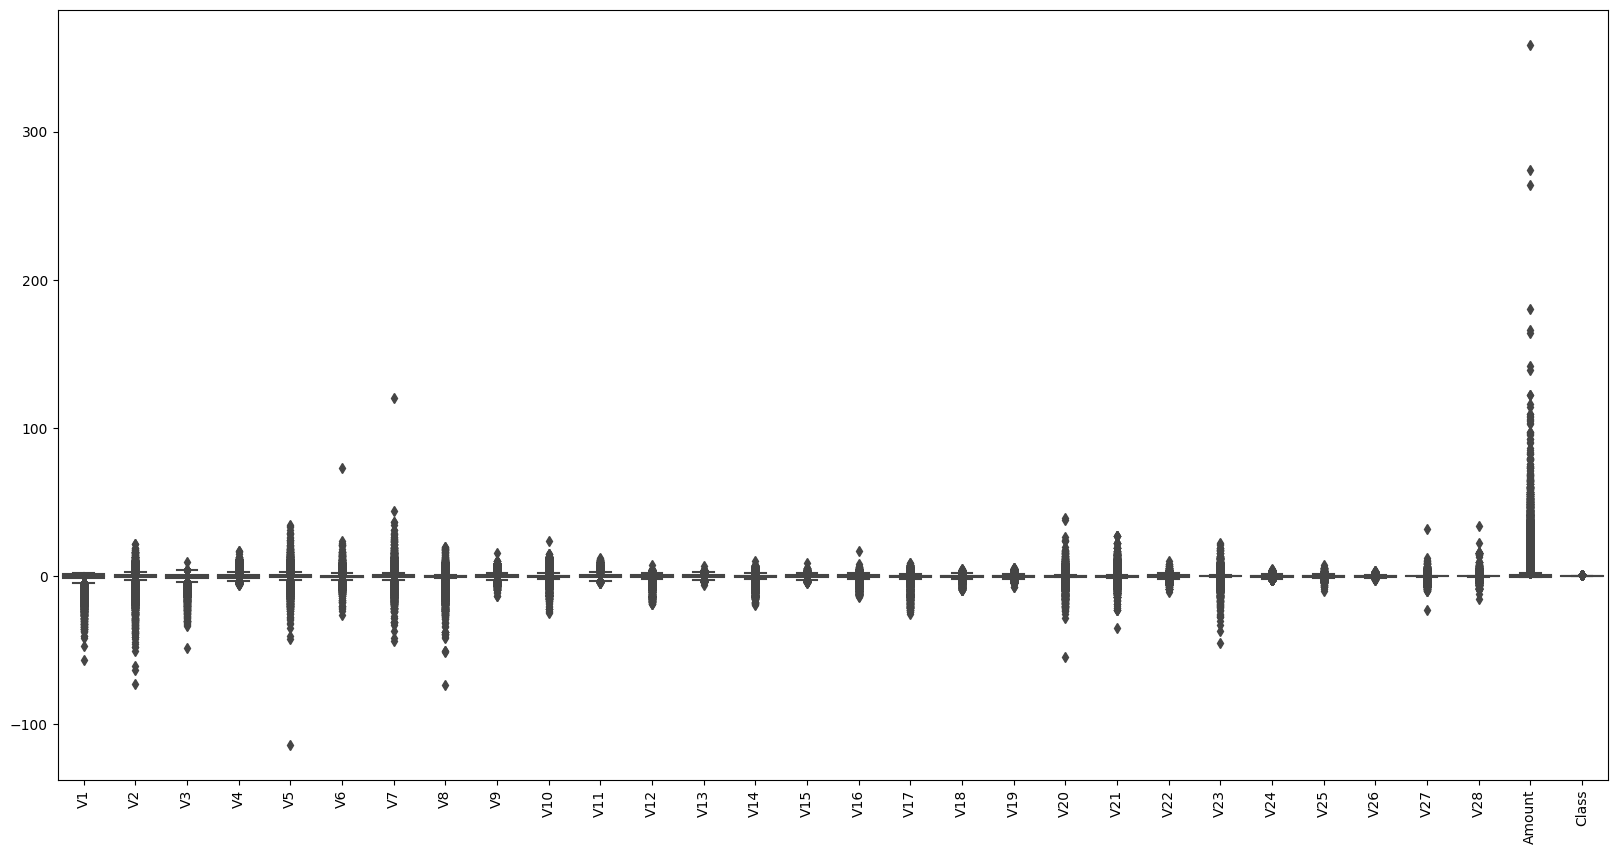

In [15]:
# Rerunning boxplot after scaling the data. 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
sns.boxplot(data=dataset)
plt.xticks(rotation=90)
plt.show()

We thus see the range of the data in the 'Amount' column has been reduced a lot. We are now going to check the range of the data of the 'Amount' column for double verification. 

In [16]:
print(dataset['Amount'].describe())

count    284807.000000
mean          0.927124
std           3.495006
min          -0.307413
25%          -0.229162
50%           0.000000
75%           0.770838
max         358.683155
Name: Amount, dtype: float64


We see that the maximum and the minimum value of the data has been reduced to a fraction to what was seen earlier. Thus RobustScaler has worked successfully and now we can now move forward.

# Splitting data for training and testing

In [17]:
# We are going to separate out the 'Class' column from out training data since we want our model to learn from the features (V1-V28) and not from the 'Class' column

Features = dataset.drop(columns = 'Class', axis = 1) #It is going to have all the columns except the 'Class' column and the 'Time' column which we had removed at the beginning of our project.
Class = dataset["Class"]

In [18]:
# Printing the newly defined Features dataset to see if the dropping has worked or not.
print(Features)

               V1         V2        V3        V4        V5        V6  \
0       -1.359807  -0.072781  2.536347  1.378155 -0.338321  0.462388   
1        1.191857   0.266151  0.166480  0.448154  0.060018 -0.082361   
2       -1.358354  -1.340163  1.773209  0.379780 -0.503198  1.800499   
3       -0.966272  -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4       -1.158233   0.877737  1.548718  0.403034 -0.407193  0.095921   
...           ...        ...       ...       ...       ...       ...   
284802 -11.881118  10.071785 -9.834783 -2.066656 -5.364473 -2.606837   
284803  -0.732789  -0.055080  2.035030 -0.738589  0.868229  1.058415   
284804   1.919565  -0.301254 -3.249640 -0.557828  2.630515  3.031260   
284805  -0.240440   0.530483  0.702510  0.689799 -0.377961  0.623708   
284806  -0.533413  -0.189733  0.703337 -0.506271 -0.012546 -0.649617   

              V7        V8        V9       V10  ...       V20       V21  \
0       0.239599  0.098698  0.363787  0.090794  ...  0.25141

In [19]:
# Printing the 'Class' column
print (Class)

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64


Thus dropping has been successful as we that the class column has been removed from the dataset.

In [20]:
# Splitting the data into training data and testing data.

from sklearn.model_selection import train_test_split # for data splitting function

#Features_train = Features (V1-V28) ->80% of data for training
#Class_train = Corresponding class values (0 or 1) ->80% of data for training

#Features_test = Features (V1-V28) ->20% of data for testing
#Class_test = Corresponding class values (0 or 1) -> 20% of data for testing

Features_train, Features_test, Class_train, Class_test = train_test_split(Features, Class, test_size = 0.2, random_state = 30, stratify = Class)
# 'Class' column has to be stratified for even distribution of 'Class' values in the training and testing datasets. 

In [21]:
# Printing our newly split datasets.
print(Features_train.shape)
print(Features_test.shape)

# Printing original dataset
print (dataset.shape)


(227845, 29)
(56962, 29)
(284807, 30)


Thus we see that splitting has been successful and for verification we can add the training and testing datasets and we would see that the number becomes same as the original dataset had.

# Training our model

In [22]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier # for using the Decision tree algorithm

tree_model = DecisionTreeClassifier(max_depth = 6, criterion = 'entropy')
tree_model.fit(Features_train, Class_train)
tree_yhat = tree_model.predict(Features_test)

In [23]:
print(cl('Performance of Decision Tree algorithm trained model', attrs = ['bold']))
print(cl('********************************************************************', attrs = ['bold']))
print(cl('Accuracy score of the Decision Tree model is {:.5f}'.format(accuracy_score(Class_test, tree_yhat)), attrs = ['bold']))
print(cl('Recall score of the Decision Tree model is {:.5f}'.format(recall_score(Class_test, tree_yhat)), attrs = ['bold']))
print(cl('Precision score of the Decision Tree model is {:.5f}'.format(precision_score(Class_test, tree_yhat)), attrs = ['bold']))
print(cl('F1 score of the Decision Tree model is {:.5f}'.format(f1_score(Class_test, tree_yhat)), attrs = ['bold']))

Performance of Decision Tree algorithm trained model
********************************************************************
Accuracy score of the Decision Tree model is 0.99939
Recall score of the Decision Tree model is 0.71429
Precision score of the Decision Tree model is 0.90909
F1 score of the Decision Tree model is 0.80000


In [24]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression # for using the Logistic regression algorithm

regression_model = LogisticRegression(max_iter = 10000) #adding max_iter function to avoid running into a ITERATIONS LIMIT eroor.
regression_model.fit(Features_train, Class_train)
regression_model_yhat = regression_model.predict(Features_test)

In [25]:
print(cl('Performance of Logistic Regression algorithm trained model', attrs = ['bold']))
print(cl('********************************************************************', attrs = ['bold']))
print(cl('Accuracy score of the LogisticRegression model is {:.5f}'.format(accuracy_score(Class_test, regression_model_yhat)), attrs = ['bold']))
print(cl('Recall score of the LogisticRegression model is {:.5f}'.format(recall_score(Class_test, regression_model_yhat)), attrs = ['bold']))
print(cl('Precision score of the LogisticRegression model is {:.5f}'.format(precision_score(Class_test, regression_model_yhat)), attrs = ['bold']))
print(cl('F1 score of the LogisticRegression model is {:.5f}'.format(f1_score(Class_test, regression_model_yhat)), attrs = ['bold']))

Performance of Logistic Regression algorithm trained model
********************************************************************
Accuracy score of the LogisticRegression model is 0.99907
Recall score of the LogisticRegression model is 0.55102
Precision score of the LogisticRegression model is 0.85714
F1 score of the LogisticRegression model is 0.67081


In [26]:
# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier # for using the KNN algorithm

n = 5

knn_model = KNeighborsClassifier(n_neighbors = n)
knn_model.fit(Features_train, Class_train)
knn_model_yhat = knn_model.predict(Features_test)

In [27]:
print(cl('Performance of KNN algorithm trained model', attrs = ['bold']))
print(cl('********************************************************', attrs = ['bold']))
print(cl('Accuracy score of the KNN model is {:.5f}'.format(accuracy_score(Class_test, knn_model_yhat)), attrs = ['bold']))
print(cl('Recall score of the KNN model is {:.5f}'.format(recall_score(Class_test, knn_model_yhat)), attrs = ['bold']))
print(cl('Precision score of the KNN model is {:.5f}'.format(precision_score(Class_test, knn_model_yhat)), attrs = ['bold']))
print(cl('F1 score of the KNN model is {:.5f}'.format(f1_score(Class_test, knn_model_yhat)), attrs = ['bold']))

Performance of KNN algorithm trained model
********************************************************
Accuracy score of the KNN model is 0.99935
Recall score of the KNN model is 0.72449
Precision score of the KNN model is 0.87654
F1 score of the KNN model is 0.79330


In [28]:
# SVM
from sklearn.svm import SVC # for using the SVM algorithm

svm_model = SVC()
svm_model.fit(Features_train, Class_train)
svm_model_yhat = svm_model.predict(Features_test)

In [29]:
print(cl('Performance of SVM algorithm trained model', attrs = ['bold']))
print(cl('********************************************************', attrs = ['bold']))
print(cl('Accuracy score of the SVM model is {:.5f}'.format(accuracy_score(Class_test, svm_model_yhat)), attrs = ['bold']))
print(cl('Recall score of the SVM model is {:.5f}'.format(recall_score(Class_test, svm_model_yhat)), attrs = ['bold']))
print(cl('Precision score of the SVM model is {:.5f}'.format(precision_score(Class_test, svm_model_yhat)), attrs = ['bold']))
print(cl('F1 score of the SVM model is {:.5f}'.format(f1_score(Class_test, svm_model_yhat)), attrs = ['bold']))

Performance of SVM algorithm trained model
********************************************************
Accuracy score of the SVM model is 0.99933
Recall score of the SVM model is 0.66327
Precision score of the SVM model is 0.92857
F1 score of the SVM model is 0.77381


In [30]:
# Random Forest Tree

from sklearn.ensemble import RandomForestClassifier # for using the Random forest tree algorithm

rf_model = RandomForestClassifier(max_depth = 6)
rf_model.fit(Features_train, Class_train)
rf_model_yhat = rf_model.predict(Features_test)

In [ ]:
print(cl('Performance of Random Forest Tree trained model', attrs = ['bold']))
print(cl('********************************************************', attrs = ['bold']))
print(cl('Accuracy score of the Random Forest Tree model is {:.5f}'.format(accuracy_score(Class_test, rf_model_yhat)), attrs = ['bold']))
print(cl('Recall score of the Random Forest Tree model is {:.5f}'.format(recall_score(Class_test, rf_model_yhat)), attrs = ['bold']))
print(cl('Precision score of the Random Forest Tree model is {:.5f}'.format(precision_score(Class_test, rf_model_yhat)), attrs = ['bold']))
print(cl('F1 score of the Random Forest Tree model is {:.5f}'.format(f1_score(Class_test, rf_model_yhat)), attrs = ['bold']))

In [ ]:
# XG Boost

from xgboost import XGBClassifier # for using the XGBoost algorithm

xgb_model = XGBClassifier(max_depth = 6)
xgb_model.fit(Features_train, Class_train)
xgb_model_yhat = xgb_model.predict(Features_test)

In [ ]:
print(cl('Performance of XG Boost trained model', attrs = ['bold']))
print(cl('********************************************************', attrs = ['bold']))
print(cl('Accuracy score of the XG Boost model is {:.5f}'.format(accuracy_score(Class_test, xgb_model_yhat)), attrs = ['bold']))
print(cl('Recall score of the XG Boost model is {:.5f}'.format(recall_score(Class_test, xgb_model_yhat)), attrs = ['bold']))
print(cl('Precision score of the XG Boost model is {:.5f}'.format(precision_score(Class_test, xgb_model_yhat)), attrs = ['bold']))
print(cl('F1 score of the XG Boost model is {:.5f}'.format(f1_score(Class_test, xgb_model_yhat)), attrs = ['bold']))

Performance of XG Boost trained model
********************************************************
Accuracy score of the XG Boost model is 0.99953
Recall score of the XG Boost model is 0.77551
Precision score of the XG Boost model is 0.93827
F1 score of the XG Boost model is 0.84916


We have thus successfully trained our model using various algorithms and we have also seen the performance each algorithm delivered to us and represented the performance metrics rounded off to 5 places of decimal.

In [ ]:
import joblib

joblib.dump(xgb_model, 'classifier.pkl')

['classifier.pkl']